# Rasterise GeoParquet To Zarr

Vector datasets can be useful in combined cubes when they are rasterised onto the same grid as other variables. This notebook turns a GeoParquet polygon layer into a categorical raster mask and stores it as Zarr.

In [18]:
from pathlib import Path


def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root when the kernel starts in a subfolder."""
    start = start.resolve()
    for path in (start, *start.parents):
        if (path / ".git").exists() or (path / "downloaded_data").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "downloaded_data"
DATA_DIR.mkdir(exist_ok=True)

import json
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray
import xarray as xr
from rasterio import features
from rasterio.transform import from_bounds

LOCAL_PARQUET = DATA_DIR / "WAIS_Jan_2017_Polygons.parquet"
ZARR_PATH = DATA_DIR / "WAIS_Jan_2017_Polygons_mask_1km.zarr"
TARGET_CRS = "EPSG:3031"
RESOLUTION_M = 1000
VALUE_COLUMN = "Feature_Cl"
ALL_TOUCHED = True
FILL_VALUE = -1


## Read And Project The Vector Layer


In [19]:
gdf = gpd.read_parquet(LOCAL_PARQUET)
gdf_3031 = gdf.to_crs(TARGET_CRS)
gdf_3031.head()


,POLY_AREA,CENTROID_X,CENTROID_Y,Area,Shape_Leng,Shape_Area,Bedrock,Coast,GL_ON_IS,Location,...,PolsbyPopp,Fractal,Reock,Schwartzbe,LW_Ratio,Feature_Cl,Elevation,Slope,Speed,geometry
0,2025.0000,-1.119980e+06,-1.183803e+06,2068.473332,210.000,2025.0000,492.707973,11674.572770,0.0,Grounded Ice,...,0.577027,1.423821,0.572958,0.759623,0.750000,Lake,340,3.70869,30.86820,"POLYGON ((-1119967.5 -1183777.5, -1119967.5 -1..."
1,450.0000,-1.120432e+06,-1.184100e+06,459.648491,90.000,450.0000,53.070199,11304.251392,0.0,Grounded Ice,...,0.698132,1.357668,0.509296,0.835543,0.500000,Lake,340,3.70869,7.49253,"POLYGON ((-1120417.5 -1184107.5, -1120447.5 -1..."
2,258750.0525,-1.120316e+06,-1.184170e+06,264298.257963,9599.995,258750.0525,0.000000,10604.111801,0.0,Grounded Ice,...,0.035282,1.359245,0.152606,0.187834,0.608549,Lake,322,3.96638,12.99670,"POLYGON ((-1120042.5 -1184167.5, -1120042.5 -1..."
3,6300.0000,-1.119911e+06,-1.183954e+06,6435.242141,600.000,6300.0000,538.188596,11491.266718,0.0,Grounded Ice,...,0.219911,1.367579,0.163535,0.468947,0.260870,Lake,340,3.70869,45.77560,"MULTIPOLYGON (((-1119937.5 -1183867.5, -111996..."
4,450.0000,-1.119870e+06,-1.184062e+06,459.656359,90.000,450.0000,629.150593,11454.003010,0.0,Grounded Ice,...,0.698132,1.357668,0.509296,0.835543,0.500000,Lake,340,3.70869,45.77560,"POLYGON ((-1119862.5 -1184077.5, -1119877.5 -1..."


## Build A 1 km Target Grid


In [20]:
minx, miny, maxx, maxy = gdf_3031.total_bounds
pad = RESOLUTION_M * 2
minx = math.floor((minx - pad) / RESOLUTION_M) * RESOLUTION_M
miny = math.floor((miny - pad) / RESOLUTION_M) * RESOLUTION_M
maxx = math.ceil((maxx + pad) / RESOLUTION_M) * RESOLUTION_M
maxy = math.ceil((maxy + pad) / RESOLUTION_M) * RESOLUTION_M

width = int((maxx - minx) / RESOLUTION_M)
height = int((maxy - miny) / RESOLUTION_M)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

x_coords = np.arange(minx + RESOLUTION_M / 2, maxx, RESOLUTION_M)
y_coords = np.arange(maxy - RESOLUTION_M / 2, miny, -RESOLUTION_M)

print(f"Grid: {width} columns x {height} rows at {RESOLUTION_M} m")


Grid: 2871 columns x 3056 rows at 1000 m


## Rasterise Categories


In [22]:
if VALUE_COLUMN in gdf_3031.columns:
    if pd.api.types.is_numeric_dtype(gdf_3031[VALUE_COLUMN]):
        values = gdf_3031[VALUE_COLUMN].fillna(FILL_VALUE).astype("uint16").to_numpy()
        category_labels = {}
    else:
        codes, labels = pd.factorize(gdf_3031[VALUE_COLUMN].astype(str), sort=True)
        values = (codes + 1).astype("uint16")
        category_labels = {int(code + 1): label for code, label in enumerate(labels)}
else:
    values = np.ones(len(gdf_3031), dtype="uint16")
    category_labels = {1: "feature_present"}

shapes = (
    (geom, int(value))
    for geom, value in zip(gdf_3031.geometry, values)
    if geom is not None and not geom.is_empty
)

raster = features.rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=FILL_VALUE,
    dtype="int16",
    all_touched=ALL_TOUCHED,
)

mask = xr.DataArray(
    raster,
    dims=("y", "x"),
    coords={"y": y_coords, "x": x_coords},
    name="supraglacial_lake_mask",
    attrs={
        "source_geoparquet": LOCAL_PARQUET.name,
        "value_column": VALUE_COLUMN,
        "fill_value": FILL_VALUE,
        "resolution_m": RESOLUTION_M,
        "all_touched": str(ALL_TOUCHED).lower(),
        "category_labels": json.dumps(category_labels),
        "feature_count": int(len(gdf_3031)),
    },
)

ds = mask.to_dataset()
ds = ds.rio.write_crs(TARGET_CRS)
ds


<xarray.Dataset> Size: 18MB
Dimensions:                 (y: 3056, x: 2871)
Coordinates:
  * y                       (y) float64 24kB 1.808e+06 1.806e+06 ... -1.248e+06
  * x                       (x) float64 23kB -2.456e+06 -2.456e+06 ... 4.135e+05
    spatial_ref             int64 8B 0
Data variables:
    supraglacial_lake_mask  (y, x) int16 18MB -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1

## Write And Validate Zarr


In [23]:
ds.to_zarr(ZARR_PATH, mode="w", consolidated=True)

/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Quicklook


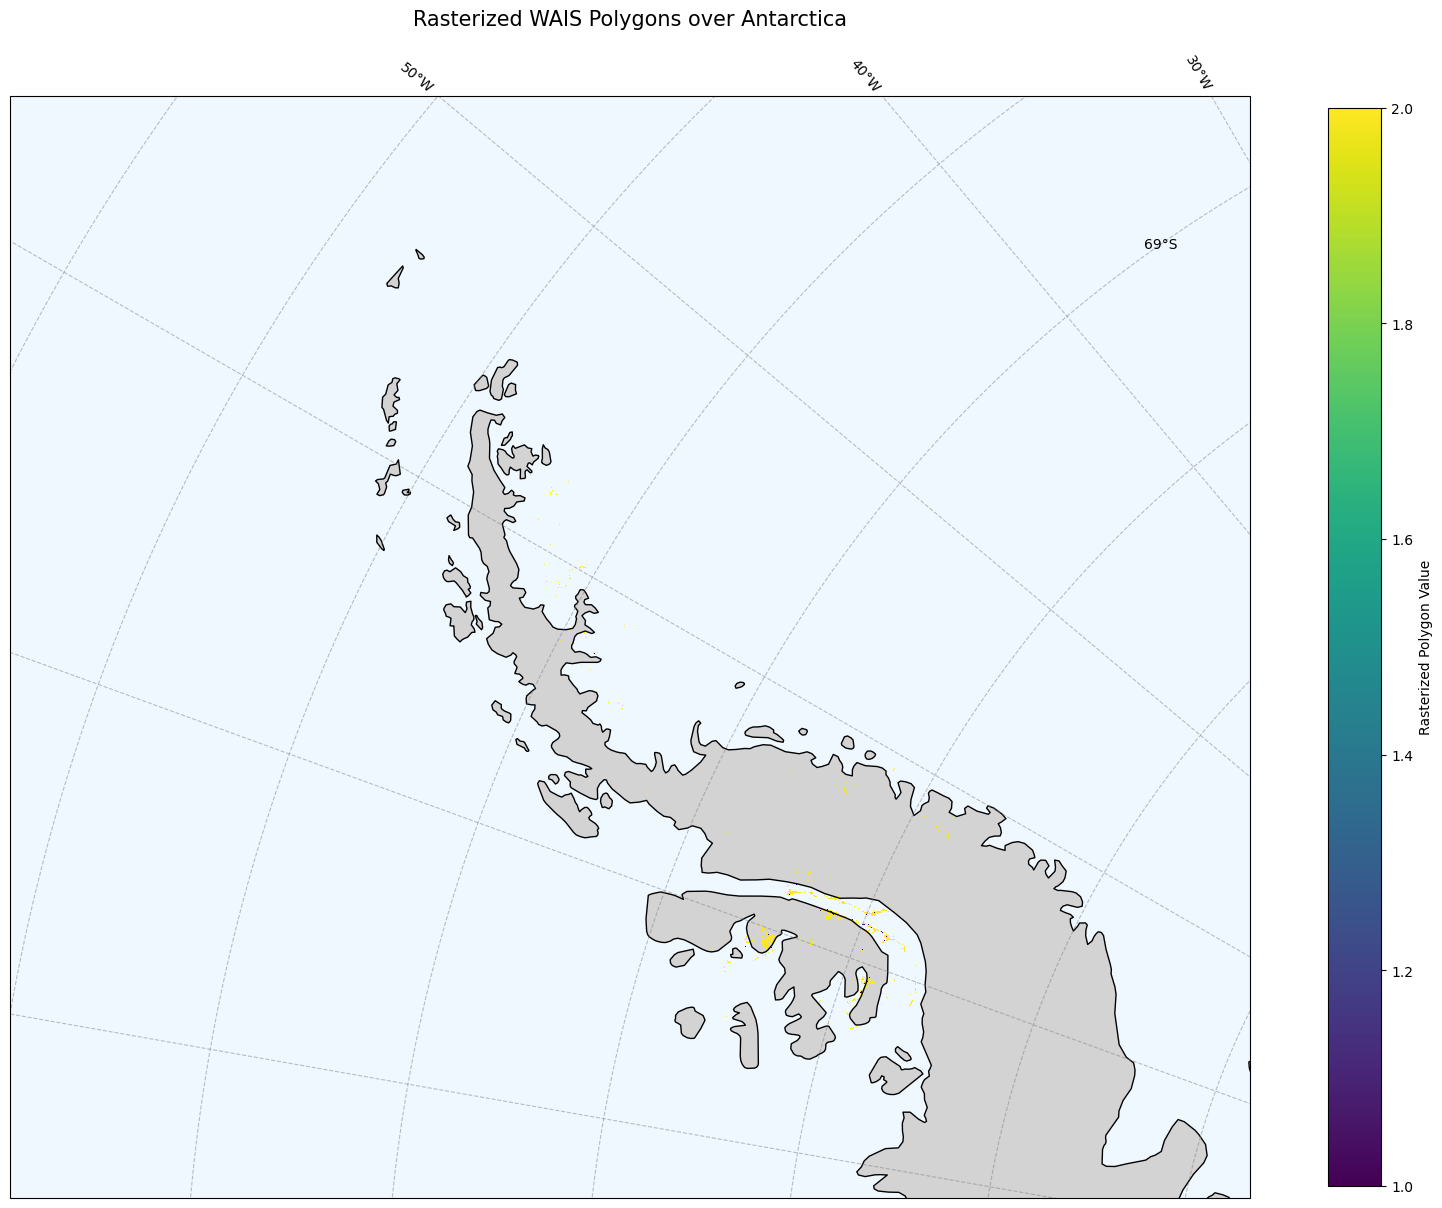

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define the projection (South Polar Stereographic = EPSG:3031)
proj = ccrs.SouthPolarStereo()

# 2. Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={'projection': proj})

# 3. Limit the map extent to Antarctica Peninsula
ax.set_extent([-80, -50, -76, -60], ccrs.PlateCarree())

# 4. Add Basemap Features
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0)
ax.coastlines(resolution='50m', color='black', linewidth=1, zorder=2)
ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')

# 5. Plot the Rasterized Data
ds['supraglacial_lake_mask'].where(ds['supraglacial_lake_mask'] != -1).plot.pcolormesh(
    ax=ax,
    x='x',
    y='y',
    transform=proj,
    cmap='viridis',
    zorder=1, 
    cbar_kwargs={
        'label': 'Rasterized Polygon Value',
        'orientation': 'vertical',
        'shrink': 0.7
    }
)

# 6. Add title and display
plt.title("Rasterized WAIS Polygons over Antarctica", fontsize=15, pad=20)
plt.show()